Successfully loaded dataset with 10000 rows.

--- Correlation Matrix ---
                                  Hours Studied  Previous Scores  Sleep Hours  \
Hours Studied                          1.000000        -0.012390     0.001245   
Previous Scores                       -0.012390         1.000000     0.005944   
Sleep Hours                            0.001245         0.005944     1.000000   
Sample Question Papers Practiced       0.017463         0.007888     0.003990   
Performance Index                      0.373730         0.915189     0.048106   

                                  Sample Question Papers Practiced  \
Hours Studied                                             0.017463   
Previous Scores                                           0.007888   
Sleep Hours                                               0.003990   
Sample Question Papers Practiced                          1.000000   
Performance Index                                         0.043268   

                   

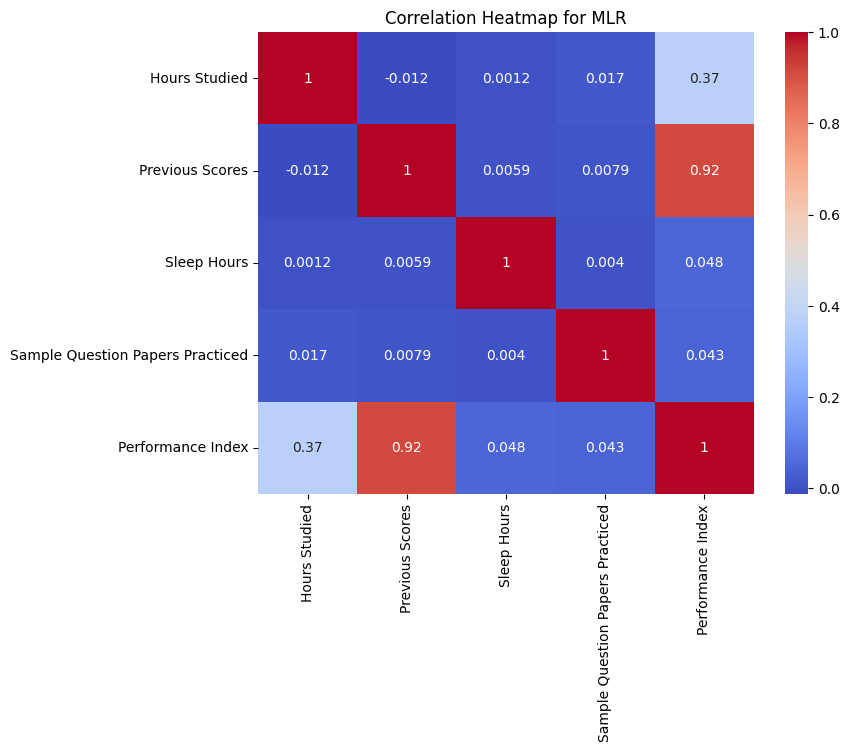


--- Model Performance ---
Intercept (c): 37.19
Coefficient for Hours Studied: 2.78
Coefficient for Sleep Hours: 0.47
Coefficient for Sample Question Papers Practiced: 0.26
Mean Squared Error: 319.97
R-squared Score: 0.14


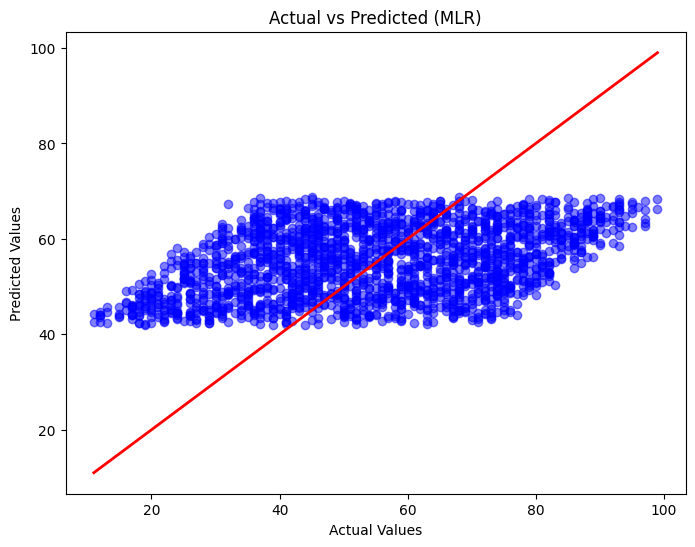

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. SETUP DATA (LOADING YOUR DATASET)
# Replace 'your_data.csv' with your actual filename

df = pd.read_csv('Student_Performance.csv')
    
# UPDATE THESE: Replace with a list of feature column names for MLR
FEATURE_COLS = ['Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced'] 
TARGET_COL = 'Performance Index'
    
print(f"Successfully loaded dataset with {len(df)} rows.")

# 2. FEATURE SELECTION & VISUALIZATION
print("\n--- Correlation Matrix ---")
# Check how all features correlate with the target
print(df.corr())

# Heatmap for visualizing multiple relationships
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap for MLR')
plt.show()

# 3. PREPARE DATA FOR MODELING
# X_data now contains multiple columns
X_data = df[FEATURE_COLS] 
y_data = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# 4. IMPLEMENT MULTIPLE LINEAR REGRESSION
model = LinearRegression()
model.fit(X_train, y_train)

# 5. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# 6. EVALUATE
print("\n--- Model Performance ---")
print(f"Intercept (c): {model.intercept_:.2f}")

# Display coefficients for each feature
for feature, coef in zip(FEATURE_COLS, model.coef_):
    print(f"Coefficient for {feature}: {coef:.2f}")

print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared Score: {r2_score(y_test, y_pred):.2f}")

# 7. VISUALIZE PREDICTIONS
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted (MLR)')
plt.show()